
# 👁️ Experiment 1 — Pupil Segmentation + Corneal/Iris Reflection Consistency CNN

This notebook trains a `real/fake` classifier directly from prepared `combined` eye ROI images.

## Pipeline

```text
Combined Eye ROI
 ├─ RGB CNN branch
 ├─ Automatic pupil segmentation
 ├─ Left/right Sobel gradient maps
 ├─ Corneal highlight maps
 └─ Pupil + gradient + highlight consistency measurements
                         ↓
                    Fusion CNN
                         ↓
                    Real / Fake
```

The notebook follows the project visualization standard:

- All figure titles, axis labels, legends, and class names are in English.
- Report figures are saved at a minimum of 1200×800 px where applicable.
- Square figures are saved at a minimum of 800×800 px.
- Every saved image is automatically checked to ensure its short edge is at least 600 px.
- Outputs are stored under a unique Run ID folder.
- Training curves, segmentation diagnostics, confusion matrix, ROC, PR, calibration, threshold analysis, prediction distributions, and error-analysis grids are generated automatically.

This experiment does **not** use HOG, LBP, GLCM, FFT, DWT, or SVM.


In [2]:

# 1) Dependencies
!pip -q install torch torchvision scikit-learn opencv-python-headless pandas matplotlib tqdm pillow


In [3]:

# 2) Drive
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [5]:

# 3) Configuration
from pathlib import Path
from datetime import datetime

DATA_ROOT = Path(
    "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Kader/Deney 1/Göz/eye_roi_output"
)
BASE_OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Kader/Deney 1/PupilReflection_FusionCNN"
)

IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2
EPOCHS = 30
PATIENCE = 7
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30
SEED = 42

# First run: keep True. Full run: set False.
SMOKE_TEST = True
SMOKE_TEST_PER_GROUP = 30

# fusion / image_only / phys_only
MODEL_MODE = "fusion"
USE_PRETRAINED = True

RUN_ID = datetime.now().strftime(
    f"%Y%m%d_%H%M_eye_pupil_reflection_{MODEL_MODE}_seed{SEED}"
)

OUTPUT_ROOT = BASE_OUTPUT_ROOT / RUN_ID
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
LOG_DIR = OUTPUT_ROOT / "logs"
METRICS_DIR = OUTPUT_ROOT / "metrics"
PREDICTIONS_DIR = OUTPUT_ROOT / "predictions"
FIGURES_DIR = OUTPUT_ROOT / "figures"
DEBUG_FIGURES_DIR = FIGURES_DIR / "segmentation_debug"
MISCLASSIFIED_DIR = FIGURES_DIR / "misclassified"

for folder in [
    OUTPUT_ROOT,
    CHECKPOINT_DIR,
    LOG_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR,
    FIGURES_DIR,
    DEBUG_FIGURES_DIR,
    MISCLASSIFIED_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Run ID:", RUN_ID)
print("Data root:", DATA_ROOT)
print("Output root:", OUTPUT_ROOT)


Run ID: 20260806_1521_eye_pupil_reflection_fusion_seed42
Data root: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Kader/Deney 1/Göz/eye_roi_output
Output root: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Kader/Deney 1/PupilReflection_FusionCNN/20260806_1521_eye_pupil_reflection_fusion_seed42


In [6]:

# 4) Importlar ve seed
import os
import math
import json
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


from sklearn.calibration import calibration_curve
from PIL import Image
import tempfile


Device: cpu


In [7]:

# 4.1) Figure and atomic-save helpers

MIN_SHORT_EDGE_PX = 600
DEFAULT_FIGSIZE = (10, 6)
DEFAULT_DPI = 150

def validate_saved_figure(path: Path, min_short_edge: int = MIN_SHORT_EDGE_PX) -> None:
    image = Image.open(path)
    if min(image.size) < min_short_edge:
        raise RuntimeError(
            f"Figure resolution is below the project standard: {path} -> {image.size}"
        )

def save_figure(
    fig,
    filename: str,
    *,
    folder: Path = FIGURES_DIR,
    dpi: int = DEFAULT_DPI,
    min_short_edge: int = MIN_SHORT_EDGE_PX,
) -> Path:
    folder.mkdir(parents=True, exist_ok=True)
    target = folder / filename
    tmp = target.with_suffix(target.suffix + ".tmp.png")
    fig.tight_layout()
    fig.savefig(tmp, dpi=dpi, bbox_inches="tight")
    validate_saved_figure(tmp, min_short_edge=min_short_edge)
    tmp.replace(target)
    plt.close(fig)
    print("Saved:", target)
    return target

def atomic_torch_save(state: dict, target: Path) -> None:
    target.parent.mkdir(parents=True, exist_ok=True)
    tmp = target.with_suffix(target.suffix + ".tmp")
    torch.save(state, tmp)

    loaded = torch.load(tmp, map_location="cpu", weights_only=False)
    required = {
        "epoch",
        "model_state_dict",
        "optimizer_state_dict",
        "scheduler_state_dict",
        "scaler_state_dict",
        "best_metric_score",
        "config",
    }
    missing = required - set(loaded.keys())
    if missing:
        raise RuntimeError(f"Checkpoint validation failed. Missing keys: {sorted(missing)}")

    os.replace(tmp, target)

def save_json_atomic(data: dict, target: Path) -> None:
    target.parent.mkdir(parents=True, exist_ok=True)
    tmp = target.with_suffix(target.suffix + ".tmp")
    tmp.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")
    os.replace(tmp, target)


In [8]:

# 5) Pupil, gradient ve highlight çıkarımı

EPS = 1e-8
SCALAR_FEATURE_NAMES = [
    "left_pupil_detected", "right_pupil_detected",
    "left_pupil_circularity", "right_pupil_circularity",
    "pupil_circularity_absdiff",
    "left_pupil_eccentricity", "right_pupil_eccentricity",
    "pupil_eccentricity_absdiff",
    "left_pupil_area_ratio", "right_pupil_area_ratio",
    "pupil_area_ratio_absdiff",
    "pupil_center_distance",
    "gradient_iou", "gradient_correlation",
    "left_highlight_count_norm", "right_highlight_count_norm",
    "highlight_count_absdiff",
    "highlight_centroid_distance",
    "highlight_area_absdiff",
]

def crop_nonblack_content(image_bgr, threshold=4):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    mask = gray > threshold
    ys, xs = np.where(mask)
    if len(xs) < 20 or len(ys) < 20:
        return image_bgr
    return image_bgr[ys.min():ys.max()+1, xs.min():xs.max()+1]

def split_combined_eyes(content_bgr):
    h, w = content_bgr.shape[:2]
    mid = w // 2
    overlap = max(2, int(w * 0.03))
    return content_bgr[:, :min(w, mid+overlap)], content_bgr[:, max(0, mid-overlap):]

def resize_pad(image, size, interpolation=cv2.INTER_AREA):
    h, w = image.shape[:2]
    if h == 0 or w == 0:
        shape = (size, size) if image.ndim == 2 else (size, size, image.shape[2])
        return np.zeros(shape, dtype=image.dtype)
    scale = min(size / w, size / h)
    nw, nh = max(1, int(round(w*scale))), max(1, int(round(h*scale)))
    resized = cv2.resize(image, (nw, nh), interpolation=interpolation)
    shape = (size, size) if image.ndim == 2 else (size, size, image.shape[2])
    canvas = np.zeros(shape, dtype=image.dtype)
    x, y = (size-nw)//2, (size-nh)//2
    canvas[y:y+nh, x:x+nw] = resized
    return canvas

def segment_pupil_approx(eye_bgr):
    gray = cv2.cvtColor(eye_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    x1, x2 = int(0.08*w), int(0.92*w)
    y1, y2 = int(0.12*h), int(0.92*h)
    core = gray[y1:y2, x1:x2]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))
    enhanced = cv2.GaussianBlur(clahe.apply(core), (5,5), 0)
    ch, cw = enhanced.shape

    thresholds = [np.percentile(enhanced, p) for p in (8, 12, 18, 24)]
    target = np.array([cw/2.0, ch/2.0])
    min_area = max(6.0, 0.001*ch*cw)
    max_area = 0.22*ch*cw
    best = None

    for level, threshold in enumerate(thresholds):
        binary = (enhanced <= threshold).astype(np.uint8)*255
        binary = cv2.morphologyEx(
            binary, cv2.MORPH_OPEN,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
        )
        binary = cv2.morphologyEx(
            binary, cv2.MORPH_CLOSE,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        )

        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        for contour in contours:
            area = cv2.contourArea(contour)
            perimeter = cv2.arcLength(contour, True)
            if not (min_area <= area <= max_area) or perimeter <= 0:
                continue

            x, y, bw, bh = cv2.boundingRect(contour)
            cx, cy = x+bw/2.0, y+bh/2.0
            center_dist = np.linalg.norm(np.array([cx, cy])-target)
            center_score = 1.0-min(1.0, center_dist/(0.75*math.hypot(cw,ch)+EPS))
            circularity = float(np.clip(4*math.pi*area/(perimeter**2+EPS), 0, 1))
            aspect = min(bw,bh)/(max(bw,bh)+EPS)

            eccentricity = 1.0
            ellipse = None
            if len(contour) >= 5:
                ellipse = cv2.fitEllipse(contour)
                (_, _), (major, minor), _ = ellipse
                a, b = max(major,minor)/2.0, min(major,minor)/2.0
                eccentricity = float(np.sqrt(max(0.0, 1.0-(b*b)/(a*a+EPS))))

            contour_mask = np.zeros_like(core)
            cv2.drawContours(contour_mask, [contour], -1, 255, -1)
            darkness = 1.0-float(core[contour_mask>0].mean()/255.0)

            score = (
                0.28*circularity + 0.20*aspect + 0.24*center_score
                + 0.18*darkness + 0.10*(1.0-eccentricity)
            )
            candidate = {
                "score": score, "contour": contour, "ellipse": ellipse,
                "circularity": circularity, "eccentricity": eccentricity,
                "area_ratio": float(area/(ch*cw+EPS)),
                "center_x": float(cx/cw), "center_y": float(cy/ch),
            }
            if best is None or score > best["score"]:
                best = candidate

    core_mask = np.zeros_like(core)
    if best is not None and best["score"] >= 0.28:
        if best["ellipse"] is not None:
            cv2.ellipse(core_mask, best["ellipse"], 255, -1)
        else:
            cv2.drawContours(core_mask, [best["contour"]], -1, 255, -1)
        info = {
            "detected": 1.0,
            "circularity": best["circularity"],
            "eccentricity": best["eccentricity"],
            "area_ratio": best["area_ratio"],
            "center_x": best["center_x"],
            "center_y": best["center_y"],
            "confidence": float(np.clip(best["score"],0,1)),
        }
    else:
        info = {
            "detected": 0.0, "circularity": np.nan,
            "eccentricity": np.nan, "area_ratio": np.nan,
            "center_x": np.nan, "center_y": np.nan,
            "confidence": 0.0,
        }

    full_mask = np.zeros_like(gray)
    full_mask[y1:y2, x1:x2] = core_mask
    return full_mask, info

def sobel_gradient_map(eye_bgr, pupil_mask):
    gray = cv2.cvtColor(eye_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3), 0)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    magnitude = cv2.magnitude(gx, gy)

    if pupil_mask.max() > 0:
        k = max(5, int(min(gray.shape)*0.24) | 1)
        region = cv2.dilate(
            pupil_mask,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)),
            iterations=1
        )
        magnitude *= region.astype(np.float32)/255.0

    return cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def highlight_map_and_info(eye_bgr, pupil_mask):
    gray = cv2.cvtColor(eye_bgr, cv2.COLOR_BGR2GRAY)
    enhanced = cv2.createCLAHE(2.0, (4,4)).apply(gray)

    if pupil_mask.max() > 0:
        k = max(5, int(min(gray.shape)*0.20) | 1)
        region = cv2.dilate(
            pupil_mask,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)),
            iterations=1
        ) > 0
    else:
        region = np.ones_like(gray, dtype=bool)

    values = enhanced[region]
    if values.size == 0:
        return np.zeros_like(gray), {
            "count": 0.0, "area_ratio": 0.0,
            "center_x": np.nan, "center_y": np.nan
        }

    threshold = max(175.0, float(np.percentile(values, 98.5)))
    mask = ((enhanced >= threshold) & region).astype(np.uint8)*255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((2,2), np.uint8))

    n, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, 8)
    valid = []
    max_area = 0.04*gray.size

    for i in range(1,n):
        area = int(stats[i, cv2.CC_STAT_AREA])
        bw = int(stats[i, cv2.CC_STAT_WIDTH])
        bh = int(stats[i, cv2.CC_STAT_HEIGHT])
        if 1 <= area <= max_area and bw > 0 and bh > 0:
            aspect = max(bw,bh)/max(1,min(bw,bh))
            if aspect <= 5.0:
                valid.append(i)

    clean = np.zeros_like(mask)
    for i in valid:
        clean[labels==i] = 255

    if valid:
        areas = np.array([stats[i,cv2.CC_STAT_AREA] for i in valid], dtype=float)
        centers = np.array([centroids[i] for i in valid], dtype=float)
        center = (centers*areas[:,None]).sum(axis=0)/(areas.sum()+EPS)
        info = {
            "count": float(len(valid)),
            "area_ratio": float(areas.sum()/gray.size),
            "center_x": float(center[0]/gray.shape[1]),
            "center_y": float(center[1]/gray.shape[0]),
        }
    else:
        info = {
            "count": 0.0, "area_ratio": 0.0,
            "center_x": np.nan, "center_y": np.nan
        }
    return clean, info

def binary_iou(a,b):
    aa, bb = a>0, b>0
    return float(np.logical_and(aa,bb).sum()/(np.logical_or(aa,bb).sum()+EPS))

def absdiff_or(a,b,fallback):
    return float(abs(a-b)) if np.isfinite(a) and np.isfinite(b) else float(fallback)

def physiological_maps_and_scalars(combined_bgr):
    content = crop_nonblack_content(combined_bgr)
    left_eye, right_eye = split_combined_eyes(content)

    left_mask, left_pupil = segment_pupil_approx(left_eye)
    right_mask, right_pupil = segment_pupil_approx(right_eye)

    left_grad = sobel_gradient_map(left_eye, left_mask)
    right_grad = sobel_gradient_map(right_eye, right_mask)
    left_high, left_hi = highlight_map_and_info(left_eye, left_mask)
    right_high, right_hi = highlight_map_and_info(right_eye, right_mask)

    size = 112
    lm = resize_pad(left_mask, size, cv2.INTER_NEAREST)
    rm = resize_pad(right_mask, size, cv2.INTER_NEAREST)
    lg = resize_pad(left_grad, size, cv2.INTER_AREA)
    rg = resize_pad(right_grad, size, cv2.INTER_AREA)
    lh = resize_pad(left_high, size, cv2.INTER_NEAREST)
    rh = resize_pad(right_high, size, cv2.INTER_NEAREST)

    lg_valid = lg[lg>0]
    rg_valid = rg[rg>0]
    lg_bin = (lg >= np.percentile(lg_valid,70)).astype(np.uint8) if lg_valid.size else np.zeros_like(lg)
    rg_bin = (rg >= np.percentile(rg_valid,70)).astype(np.uint8) if rg_valid.size else np.zeros_like(rg)
    grad_iou = binary_iou(lg_bin, rg_bin)

    if lg.std()>0 and rg.std()>0:
        grad_corr = float(np.corrcoef(lg.ravel(),rg.ravel())[0,1])
        if not np.isfinite(grad_corr):
            grad_corr = 0.0
    else:
        grad_corr = 0.0

    if all(np.isfinite([
        left_pupil["center_x"], left_pupil["center_y"],
        right_pupil["center_x"], right_pupil["center_y"]
    ])):
        pupil_center_distance = float(math.hypot(
            left_pupil["center_x"]-right_pupil["center_x"],
            left_pupil["center_y"]-right_pupil["center_y"]
        ))
    else:
        pupil_center_distance = 1.0

    if all(np.isfinite([
        left_hi["center_x"], left_hi["center_y"],
        right_hi["center_x"], right_hi["center_y"]
    ])):
        highlight_center_distance = float(math.hypot(
            left_hi["center_x"]-right_hi["center_x"],
            left_hi["center_y"]-right_hi["center_y"]
        ))
    else:
        highlight_center_distance = 1.0

    scalars = np.array([
        left_pupil["detected"], right_pupil["detected"],
        np.nan_to_num(left_pupil["circularity"], nan=0.0),
        np.nan_to_num(right_pupil["circularity"], nan=0.0),
        absdiff_or(left_pupil["circularity"],right_pupil["circularity"],1.0),
        np.nan_to_num(left_pupil["eccentricity"], nan=1.0),
        np.nan_to_num(right_pupil["eccentricity"], nan=1.0),
        absdiff_or(left_pupil["eccentricity"],right_pupil["eccentricity"],1.0),
        np.nan_to_num(left_pupil["area_ratio"], nan=0.0),
        np.nan_to_num(right_pupil["area_ratio"], nan=0.0),
        absdiff_or(left_pupil["area_ratio"],right_pupil["area_ratio"],1.0),
        pupil_center_distance,
        grad_iou, grad_corr,
        min(left_hi["count"],10.0)/10.0,
        min(right_hi["count"],10.0)/10.0,
        abs(left_hi["count"]-right_hi["count"])/10.0,
        highlight_center_distance,
        abs(left_hi["area_ratio"]-right_hi["area_ratio"]),
    ], dtype=np.float32)

    maps = np.stack([lm,rm,lg,rg,lh,rh], axis=0).astype(np.float32)/255.0

    debug = {
        "content": content, "left_eye": left_eye, "right_eye": right_eye,
        "left_pupil_mask": left_mask, "right_pupil_mask": right_mask,
        "left_gradient": left_grad, "right_gradient": right_grad,
        "left_highlight": left_high, "right_highlight": right_high,
        "scalars": dict(zip(SCALAR_FEATURE_NAMES, scalars.tolist()))
    }
    return maps, scalars, debug


In [9]:

# 6) Veri indeksleme
SUPPORTED_EXT = {".jpg",".jpeg",".png",".bmp",".webp"}

def resolve_combined_folder(root, label, split):
    candidates = [
        root/label/split/"combined",
        root/label.capitalize()/split/"combined",
        root/label/split.capitalize()/"combined",
    ]
    return next((p for p in candidates if p.exists()), candidates[0])

def collect_samples(root, split):
    rows = []
    for label_name, label_value in [("real",0),("fake",1)]:
        folder = resolve_combined_folder(root,label_name,split)
        files = sorted([
            p for p in folder.rglob("*")
            if p.is_file() and p.suffix.lower() in SUPPORTED_EXT
        ])
        if SMOKE_TEST:
            files = files[:SMOKE_TEST_PER_GROUP]
        rows += [{
            "path": str(p), "label": label_value,
            "label_name": label_name, "split": split
        } for p in files]
    return pd.DataFrame(rows)

index_frames = {s: collect_samples(DATA_ROOT,s) for s in ("train","val","test")}

for split, frame in index_frames.items():
    print(split, len(frame), frame["label_name"].value_counts().to_dict() if len(frame) else {})

assert all(len(df)>0 for df in index_frames.values()), "Splitlerden biri boş."
pd.concat(index_frames.values()).to_csv(
    OUTPUT_ROOT/"dataset_index.csv", index=False, encoding="utf-8-sig"
)


train 60 {'real': 30, 'fake': 30}
val 60 {'real': 30, 'fake': 30}
test 60 {'real': 30, 'fake': 30}



## Dataset Visualizations

The following figures are generated before training:

1. Class distribution by split  
2. Random combined-eye examples  
3. Image-size distribution  
4. Mean image per class  
5. Pupil, gradient, and highlight diagnostic panels  


Saved: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Kader/Deney 1/PupilReflection_FusionCNN/20260806_1521_eye_pupil_reflection_fusion_seed42/figures/01_dataset_distribution.png
Saved: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Kader/Deney 1/PupilReflection_FusionCNN/20260806_1521_eye_pupil_reflection_fusion_seed42/figures/02_random_combined_eye_samples.png
Saved: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Kader/Deney 1/PupilReflection_FusionCNN/20260806_1521_eye_pupil_reflection_fusion_seed42/figures/03_image_size_distribution.png


RuntimeError: Figure resolution is below the project standard: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Kader/Deney 1/PupilReflection_FusionCNN/20260806_1521_eye_pupil_reflection_fusion_seed42/figures/04_mean_images_by_class.png.tmp.png -> (1467, 759)

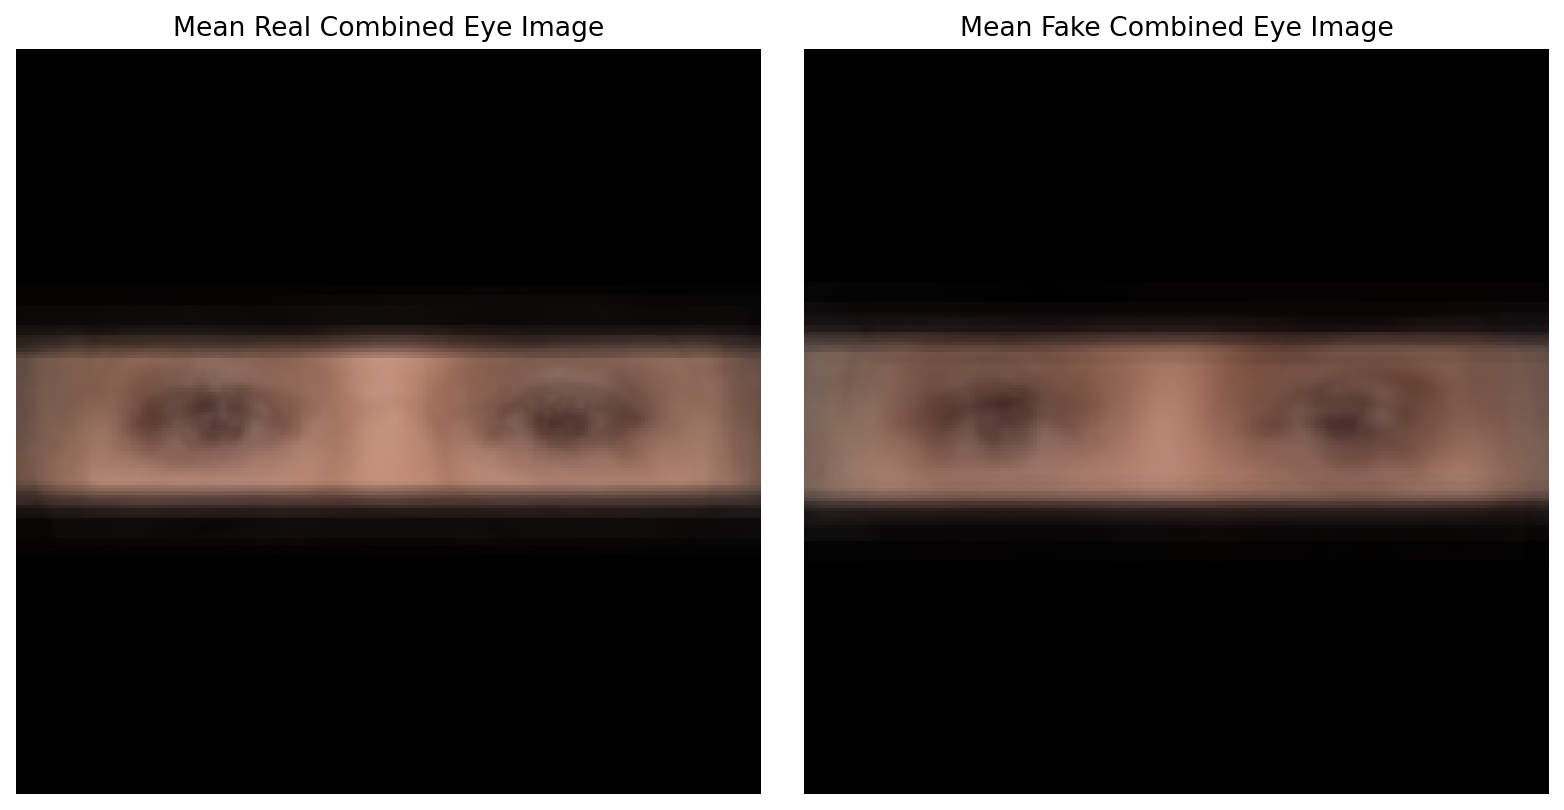

In [10]:

# Dataset visualizations

all_index_df = pd.concat(index_frames.values(), ignore_index=True)

# 1) Class distribution by split
counts = (
    all_index_df.groupby(["split", "label_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(["train", "val", "test"])
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
counts.plot(kind="bar", ax=ax)
ax.set_title("Dataset Distribution by Split and Class", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Dataset Split", fontsize=11)
ax.set_ylabel("Number of Samples", fontsize=11)
ax.legend(title="Class", labels=["Fake", "Real"] if list(counts.columns) == ["fake", "real"] else None)
ax.grid(True, axis="y", alpha=0.25)
save_figure(fig, "01_dataset_distribution.png")

# 2) Random sample grid
rng = np.random.default_rng(SEED)
sample_rows = []
for split in ["train", "val", "test"]:
    for label_name in ["real", "fake"]:
        subset = all_index_df[
            (all_index_df["split"] == split) &
            (all_index_df["label_name"] == label_name)
        ]
        if len(subset):
            sample_rows.append(subset.iloc[int(rng.integers(0, len(subset)))])

fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=150)
for ax, row in zip(axes.ravel(), sample_rows):
    image = cv2.imread(row["path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax.imshow(image)
    ax.set_title(f"{row['split'].title()} — {row['label_name'].title()}", fontsize=12)
    ax.axis("off")
save_figure(fig, "02_random_combined_eye_samples.png", min_short_edge=800)

# 3) Image size distribution
size_rows = []
for path in all_index_df["path"]:
    image = cv2.imread(path)
    if image is not None:
        h, w = image.shape[:2]
        size_rows.append((w, h))

size_df = pd.DataFrame(size_rows, columns=["width", "height"])
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.scatter(size_df["width"], size_df["height"], alpha=0.55)
ax.set_title("Combined Eye ROI Size Distribution", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Width (pixels)", fontsize=11)
ax.set_ylabel("Height (pixels)", fontsize=11)
ax.grid(True, alpha=0.25)
save_figure(fig, "03_image_size_distribution.png")

# 4) Mean image per class (train only)
mean_images = {}
for label_name in ["real", "fake"]:
    subset = index_frames["train"][index_frames["train"]["label_name"] == label_name]
    accumulator = None
    count = 0
    for path in subset["path"]:
        image = cv2.imread(path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE)).astype(np.float32)
        accumulator = image if accumulator is None else accumulator + image
        count += 1
    if count:
        mean_images[label_name] = np.clip(accumulator / count, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=160)
for ax, label_name in zip(axes, ["real", "fake"]):
    if label_name in mean_images:
        ax.imshow(mean_images[label_name])
    ax.set_title(f"Mean {label_name.title()} Combined Eye Image", fontsize=12)
    ax.axis("off")
save_figure(fig, "04_mean_images_by_class.png", min_short_edge=800)


In [ ]:

# 7) Dataset ve DataLoader
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.12,contrast=0.12,saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class EyeConsistencyDataset(Dataset):
    def __init__(self, frame, transform, cache=False):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.cache = {} if cache else None

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        path = row["path"]
        bgr = cv2.imread(path)
        if bgr is None:
            raise RuntimeError(f"Okunamadı: {path}")
        rgb = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
        rgb_tensor = self.transform(rgb)

        if self.cache is not None and path in self.cache:
            maps, scalars = self.cache[path]
        else:
            maps, scalars, _ = physiological_maps_and_scalars(bgr)
            if self.cache is not None:
                self.cache[path] = (maps,scalars)

        return {
            "rgb": rgb_tensor,
            "phys_maps": torch.from_numpy(maps),
            "scalars": torch.from_numpy(scalars),
            "label": torch.tensor(float(row["label"]),dtype=torch.float32),
            "path": path,
        }

train_ds = EyeConsistencyDataset(index_frames["train"],train_transform,cache=False)
val_ds = EyeConsistencyDataset(index_frames["val"],eval_transform,cache=True)
test_ds = EyeConsistencyDataset(index_frames["test"],eval_transform,cache=True)

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=True,generator=g)
val_loader = DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)
test_loader = DataLoader(test_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)


In [ ]:

# 8) Segmentation diagnostic figures

def save_debug_examples(dataset, n=8):
    indices = np.linspace(0, len(dataset)-1, min(n, len(dataset)), dtype=int)
    scalar_rows = []

    for order, idx in enumerate(indices):
        row = dataset.frame.iloc[idx]
        bgr = cv2.imread(row["path"])
        _, _, debug = physiological_maps_and_scalars(bgr)

        fig, axes = plt.subplots(2, 4, figsize=(14, 8), dpi=150)
        items = [
            ("Left Eye", cv2.cvtColor(debug["left_eye"], cv2.COLOR_BGR2RGB), None),
            ("Left Pupil Mask", debug["left_pupil_mask"], "gray"),
            ("Left Gradient Map", debug["left_gradient"], "gray"),
            ("Left Highlight Map", debug["left_highlight"], "gray"),
            ("Right Eye", cv2.cvtColor(debug["right_eye"], cv2.COLOR_BGR2RGB), None),
            ("Right Pupil Mask", debug["right_pupil_mask"], "gray"),
            ("Right Gradient Map", debug["right_gradient"], "gray"),
            ("Right Highlight Map", debug["right_highlight"], "gray"),
        ]

        for ax, (title, data, cmap) in zip(axes.ravel(), items):
            ax.imshow(data, cmap=cmap)
            ax.set_title(title, fontsize=11)
            ax.axis("off")

        fig.suptitle(
            f"Segmentation Diagnostic — {row['label_name'].title()} — {Path(row['path']).name}",
            fontsize=14,
            fontweight="bold",
        )

        save_figure(
            fig,
            f"segmentation_debug_{order:02d}_{row['label_name']}.png",
            folder=DEBUG_FIGURES_DIR,
            min_short_edge=800,
        )

        scalar_rows.append({
            "path": row["path"],
            "label": row["label_name"],
            **debug["scalars"],
        })

    scalar_df = pd.DataFrame(scalar_rows)
    scalar_df.to_csv(
        METRICS_DIR / "segmentation_scalar_debug.csv",
        index=False,
        encoding="utf-8-sig",
    )
    return scalar_df

segmentation_debug_df = save_debug_examples(train_ds, n=8)
display(segmentation_debug_df.head())


In [ ]:

# 8.1) Pupil and reflection scalar distributions

audit_rows = []
for _, row in index_frames["train"].iterrows():
    image = cv2.imread(row["path"])
    if image is None:
        continue
    _, scalars, _ = physiological_maps_and_scalars(image)
    audit_rows.append({
        "label": row["label_name"],
        **dict(zip(SCALAR_FEATURE_NAMES, scalars.tolist())),
    })

scalar_audit_df = pd.DataFrame(audit_rows)
scalar_audit_df.to_csv(
    METRICS_DIR / "train_physiological_scalar_features.csv",
    index=False,
    encoding="utf-8-sig",
)

selected_scalar_features = [
    "left_pupil_circularity",
    "right_pupil_circularity",
    "pupil_circularity_absdiff",
    "pupil_eccentricity_absdiff",
    "pupil_area_ratio_absdiff",
    "gradient_iou",
    "gradient_correlation",
    "highlight_count_absdiff",
    "highlight_centroid_distance",
]

for feature in selected_scalar_features:
    if feature not in scalar_audit_df.columns:
        continue

    real_values = pd.to_numeric(
        scalar_audit_df.loc[scalar_audit_df["label"] == "real", feature],
        errors="coerce",
    ).dropna()
    fake_values = pd.to_numeric(
        scalar_audit_df.loc[scalar_audit_df["label"] == "fake", feature],
        errors="coerce",
    ).dropna()

    if len(real_values) < 2 or len(fake_values) < 2:
        continue

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    ax.hist(real_values, bins=25, alpha=0.60, density=True, label="Real")
    ax.hist(fake_values, bins=25, alpha=0.60, density=True, label="Fake")
    ax.set_title(
        f"Real vs Fake Distribution — {feature.replace('_', ' ').title()}",
        fontsize=14,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel(feature.replace("_", " ").title(), fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.25)
    save_figure(fig, f"physiology_{feature}.png")



**Bu görselleri kontrol et:** Pupil maskeleri göz bebeğine oturmuyorsa tam eğitimi başlatma.


In [ ]:

# 9) Fusion CNN modeli
class PhysMapCNN(nn.Module):
    def __init__(self,out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(6,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(128,out_dim)

    def forward(self,x):
        return self.fc(self.net(x).flatten(1))

def build_resnet18():
    try:
        weights = models.ResNet18_Weights.DEFAULT if USE_PRETRAINED else None
        net = models.resnet18(weights=weights)
    except Exception as exc:
        print("Pretrained yüklenemedi:",exc)
        net = models.resnet18(weights=None)
    dim = net.fc.in_features
    net.fc = nn.Identity()
    return net,dim

class PupilReflectionFusionNet(nn.Module):
    def __init__(self,mode="fusion"):
        super().__init__()
        self.mode = mode
        self.rgb,rgb_dim = build_resnet18()
        self.phys = PhysMapCNN(128)
        self.scalar = nn.Sequential(
            nn.Linear(len(SCALAR_FEATURE_NAMES),64),
            nn.BatchNorm1d(64),nn.ReLU(),nn.Dropout(DROPOUT),
            nn.Linear(64,64),nn.ReLU()
        )
        dim = rgb_dim if mode=="image_only" else 192 if mode=="phys_only" else rgb_dim+192
        self.head = nn.Sequential(
            nn.Linear(dim,256),nn.ReLU(),nn.Dropout(DROPOUT),
            nn.Linear(256,64),nn.ReLU(),nn.Dropout(DROPOUT),
            nn.Linear(64,1)
        )

    def forward(self,rgb,maps,scalars):
        parts = []
        if self.mode in ("fusion","image_only"):
            parts.append(self.rgb(rgb))
        if self.mode in ("fusion","phys_only"):
            parts += [self.phys(maps),self.scalar(scalars)]
        return self.head(torch.cat(parts,dim=1)).squeeze(1)

model = PupilReflectionFusionNet(MODEL_MODE).to(DEVICE)
print("Parameters:",sum(p.numel() for p in model.parameters() if p.requires_grad))


In [ ]:

# 10) Eğitim yardımcıları
labels_np = index_frames["train"]["label"].to_numpy()
n0 = max(1,int((labels_np==0).sum()))
n1 = max(1,int((labels_np==1).sum()))
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([n0/n1],device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=2)
scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type=="cuda")

def metrics(y_true,y_prob,threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob>=threshold).astype(int)
    cm = confusion_matrix(y_true,y_pred,labels=[0,1])
    tn,fp,fn,tp = cm.ravel()
    result = {
        "accuracy": accuracy_score(y_true,y_pred),
        "precision": precision_score(y_true,y_pred,zero_division=0),
        "recall_sensitivity": recall_score(y_true,y_pred,zero_division=0),
        "specificity": tn/(tn+fp+EPS),
        "f1": f1_score(y_true,y_pred,zero_division=0),
        "roc_auc": roc_auc_score(y_true,y_prob) if len(np.unique(y_true))==2 else np.nan,
        "pr_auc": average_precision_score(y_true,y_prob) if len(np.unique(y_true))==2 else np.nan,
    }
    return result,cm,y_pred

def run_epoch(loader,training):
    model.train(training)
    total_loss = 0.0
    ys,ps,paths = [],[],[]

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in tqdm(loader,leave=False):
            rgb = batch["rgb"].to(DEVICE)
            maps = batch["phys_maps"].to(DEVICE)
            scalars_batch = batch["scalars"].to(DEVICE)
            y = batch["label"].to(DEVICE)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=DEVICE.type=="cuda"):
                logits = model(rgb,maps,scalars_batch)
                loss = criterion(logits,y)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(),5.0)
                scaler.step(optimizer)
                scaler.update()

            prob = torch.sigmoid(logits)
            total_loss += loss.item()*len(y)
            ys += y.detach().cpu().tolist()
            ps += prob.detach().cpu().tolist()
            paths += list(batch["path"])

    result,cm,pred = metrics(ys,ps)
    return total_loss/max(1,len(loader.dataset)),result,ys,ps,pred,paths


In [ ]:

# 11) Eğitim ve checkpoint
best_checkpoint_path = CHECKPOINT_DIR / "best.ckpt"
last_checkpoint_path = CHECKPOINT_DIR / "last.ckpt"
history = []
best = -np.inf
wait = 0

for epoch in range(1,EPOCHS+1):
    train_loss,train_m,*_ = run_epoch(train_loader,True)
    val_loss,val_m,*_ = run_epoch(val_loader,False)

    score = val_m["roc_auc"] if np.isfinite(val_m["roc_auc"]) else val_m["f1"]
    scheduler.step(score)

    row = {
        "epoch": epoch, "lr": optimizer.param_groups[0]["lr"], "train_loss": train_loss, "val_loss": val_loss,
        **{f"train_{k}":v for k,v in train_m.items()},
        **{f"val_{k}":v for k,v in val_m.items()},
    }
    history.append(row)
    print(epoch,row)

    if score > best+1e-5:
        best = score
        wait = 0
        checkpoint_state = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_metric_score": best,
            "config": {
                "run_id": RUN_ID,
                "model_mode": MODEL_MODE,
                "image_size": IMAGE_SIZE,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "dropout": DROPOUT,
                "seed": SEED,
            },
            "scalar_features": SCALAR_FEATURE_NAMES,
            "torch_rng_state": torch.get_rng_state(),
            "cuda_rng_state": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        }
        atomic_torch_save(checkpoint_state, best_checkpoint_path)
    else:
        wait += 1

    last_state = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_metric_score": best,
        "config": {
            "run_id": RUN_ID,
            "model_mode": MODEL_MODE,
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "dropout": DROPOUT,
            "seed": SEED,
        },
        "scalar_features": SCALAR_FEATURE_NAMES,
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }
    atomic_torch_save(last_state, last_checkpoint_path)

    pd.DataFrame(history).to_csv(
        LOG_DIR / "training_history.csv",
        index=False,
        encoding="utf-8-sig",
    )

    if wait>=PATIENCE:
        print("Early stopping")
        break


In [ ]:

# 12) Training and validation visualizations

history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss",
    linewidth=2,
)
ax.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
    linewidth=2,
    linestyle="--",
)
ax.set_title("Training and Validation Loss Curve", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)
ax.legend(frameon=True, loc="upper right")
ax.grid(True, alpha=0.25)
save_figure(fig, "10_training_validation_loss.png")

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(history_df["epoch"], history_df["val_roc_auc"], label="Validation ROC-AUC", linewidth=2)
ax.plot(history_df["epoch"], history_df["val_f1"], label="Validation F1-Score", linewidth=2)
ax.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy", linewidth=2)
ax.set_title("Validation Performance by Epoch", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.02)
ax.legend(frameon=True, loc="lower right")
ax.grid(True, alpha=0.25)
save_figure(fig, "11_validation_metrics.png")

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(history_df["epoch"], history_df["lr"], label="Learning Rate", linewidth=2)
ax.set_title("Learning Rate Schedule", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Learning Rate", fontsize=11)
ax.set_yscale("log")
ax.grid(True, alpha=0.25)
save_figure(fig, "12_learning_rate_schedule.png")


In [ ]:

# 13) Test
ckpt = torch.load(best_checkpoint_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])

test_loss,test_m,y_true,y_prob,y_pred,test_paths = run_epoch(test_loader,False)
print(json.dumps(test_m,indent=2))
print(classification_report(y_true,y_pred,target_names=["real","fake"],digits=4,zero_division=0))

pd.DataFrame({
    "path":test_paths,"y_true":y_true,
    "y_prob_fake":y_prob,"y_pred":y_pred
}).to_csv(PREDICTIONS_DIR / "test_predictions.csv",index=False,encoding="utf-8-sig")

(METRICS_DIR / "test_metrics.json").write_text(
    json.dumps({"test_loss":test_loss,**test_m},indent=2),
    encoding="utf-8"
)


In [ ]:

# 14) Test-result visualizations

test_metrics, cm, _ = metrics(y_true, y_prob)

# 14.1 Confusion matrix
fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
image = ax.imshow(cm)
ax.set_title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold", pad=12)
ax.set_xticks([0, 1], labels=["Real", "Fake"])
ax.set_yticks([0, 1], labels=["Real", "Fake"])
ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("True Class", fontsize=11)

for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=16)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
save_figure(fig, "20_confusion_matrix.png", min_short_edge=800)

# 14.2 ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(fpr, tpr, linewidth=2, label=f"Fusion CNN (AUC = {test_m['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random Classifier")
ax.set_title("Receiver Operating Characteristic Curve", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(frameon=True, loc="lower right")
ax.grid(True, alpha=0.25)
save_figure(fig, "21_roc_curve.png")

# 14.3 Precision–Recall curve
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_true, y_prob)
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(
    recall_values,
    precision_values,
    linewidth=2,
    label=f"Fusion CNN (AP = {test_m['pr_auc']:.4f})",
)
ax.set_title("Precision–Recall Curve", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.legend(frameon=True, loc="lower left")
ax.grid(True, alpha=0.25)
save_figure(fig, "22_precision_recall_curve.png")

# 14.4 Prediction probability distribution
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
real_probabilities = np.asarray(y_prob)[np.asarray(y_true) == 0]
fake_probabilities = np.asarray(y_prob)[np.asarray(y_true) == 1]
ax.hist(real_probabilities, bins=25, alpha=0.65, density=True, label="Real Samples")
ax.hist(fake_probabilities, bins=25, alpha=0.65, density=True, label="Fake Samples")
ax.axvline(0.5, linestyle="--", linewidth=2, label="Decision Threshold = 0.50")
ax.set_title("Predicted Fake-Probability Distribution", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Probability of Fake", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.25)
save_figure(fig, "23_prediction_probability_distribution.png")

# 14.5 Calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
ax.plot(prob_pred, prob_true, marker="o", linewidth=2, label="Fusion CNN")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Perfect Calibration")
ax.set_title("Calibration Curve", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Mean Predicted Probability", fontsize=11)
ax.set_ylabel("Observed Fake Frequency", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.25)
save_figure(fig, "24_calibration_curve.png", min_short_edge=800)

# 14.6 Threshold sweep
threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 19):
    result, _, _ = metrics(y_true, y_prob, threshold=float(threshold))
    threshold_rows.append({
        "threshold": float(threshold),
        **result,
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(
    METRICS_DIR / "threshold_analysis.csv",
    index=False,
    encoding="utf-8-sig",
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
for metric_name, display_name in [
    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall_sensitivity", "Recall / Sensitivity"),
    ("specificity", "Specificity"),
    ("f1", "F1-Score"),
]:
    ax.plot(
        threshold_df["threshold"],
        threshold_df[metric_name],
        linewidth=2,
        label=display_name,
    )

ax.set_title("Decision-Threshold Performance Analysis", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Decision Threshold", fontsize=11)
ax.set_ylabel("Metric Score", fontsize=11)
ax.set_ylim(0, 1.02)
ax.legend(ncol=2)
ax.grid(True, alpha=0.25)
save_figure(fig, "25_threshold_analysis.png")

# 14.7 Test metric summary
metric_names = [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "roc_auc",
    "pr_auc",
]
metric_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC",
]
metric_values = [float(test_m[name]) for name in metric_names]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
bars = ax.bar(metric_labels, metric_values)
ax.set_title("Test-Set Performance Summary", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Metric", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=30)
ax.grid(True, axis="y", alpha=0.25)

for bar, value in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

save_figure(fig, "26_test_metric_summary.png")



## Error Analysis Visualizations

The following outputs show:

- Highest-confidence false positives  
- Highest-confidence false negatives  
- Correct high-confidence predictions  
- Per-sample probability and true/predicted class  


In [ ]:

# 15) Error-analysis grids

predictions_df = pd.DataFrame({
    "path": test_paths,
    "y_true": y_true,
    "y_prob_fake": y_prob,
    "y_pred": y_pred,
})
predictions_df["true_class"] = predictions_df["y_true"].map({0: "Real", 1: "Fake"})
predictions_df["predicted_class"] = predictions_df["y_pred"].map({0: "Real", 1: "Fake"})
predictions_df["confidence"] = np.where(
    predictions_df["y_pred"] == 1,
    predictions_df["y_prob_fake"],
    1.0 - predictions_df["y_prob_fake"],
)
predictions_df["error_type"] = np.select(
    [
        (predictions_df["y_true"] == 0) & (predictions_df["y_pred"] == 1),
        (predictions_df["y_true"] == 1) & (predictions_df["y_pred"] == 0),
    ],
    ["False Positive", "False Negative"],
    default="Correct",
)

predictions_df.to_csv(
    PREDICTIONS_DIR / "test_predictions_detailed.csv",
    index=False,
    encoding="utf-8-sig",
)

def save_prediction_grid(frame, title, filename, max_items=12):
    frame = frame.head(max_items)
    if len(frame) == 0:
        print(f"No samples available for: {title}")
        return

    ncols = 4
    nrows = math.ceil(len(frame) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.7 * nrows), dpi=150)
    axes = np.asarray(axes).reshape(-1)

    for ax, (_, row) in zip(axes, frame.iterrows()):
        image = cv2.imread(row["path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        ax.imshow(image)
        ax.set_title(
            f"True: {row['true_class']} | Pred: {row['predicted_class']}\n"
            f"P(Fake): {row['y_prob_fake']:.3f}",
            fontsize=10,
        )
        ax.axis("off")

    for ax in axes[len(frame):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=15, fontweight="bold")
    save_figure(fig, filename, folder=MISCLASSIFIED_DIR, min_short_edge=800)

false_positives = predictions_df[
    predictions_df["error_type"] == "False Positive"
].sort_values("confidence", ascending=False)

false_negatives = predictions_df[
    predictions_df["error_type"] == "False Negative"
].sort_values("confidence", ascending=False)

correct_high_confidence = predictions_df[
    predictions_df["error_type"] == "Correct"
].sort_values("confidence", ascending=False)

save_prediction_grid(
    false_positives,
    "Highest-Confidence False Positives",
    "false_positives.png",
)
save_prediction_grid(
    false_negatives,
    "Highest-Confidence False Negatives",
    "false_negatives.png",
)
save_prediction_grid(
    correct_high_confidence,
    "Highest-Confidence Correct Predictions",
    "correct_predictions.png",
)

error_summary = (
    predictions_df["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)
error_summary.to_csv(
    METRICS_DIR / "error_analysis_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
display(error_summary)



## Grad-CAM Visualization

Grad-CAM is generated for the RGB branch when `MODEL_MODE` is `fusion` or `image_only`.  
It highlights image regions that most influenced the fake-probability prediction.


In [ ]:

# 16) Grad-CAM for the RGB branch

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, rgb, phys_maps, scalars):
        self.model.zero_grad(set_to_none=True)
        logit = self.model(rgb, phys_maps, scalars)
        logit.sum().backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(
            cam,
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode="bilinear",
            align_corners=False,
        )

        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        cam /= cam.max() + EPS
        return cam

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

if MODEL_MODE in {"fusion", "image_only"}:
    grad_cam = GradCAM(model, model.rgb.layer4[-1])

    selected_rows = predictions_df.sort_values(
        "confidence",
        ascending=False,
    ).head(8)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=150)
    for ax, (_, row) in zip(axes.ravel(), selected_rows.iterrows()):
        bgr = cv2.imread(row["path"])
        rgb_image = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        _, scalars_np, _ = physiological_maps_and_scalars(bgr)
        phys_maps_np, _, _ = physiological_maps_and_scalars(bgr)

        rgb_tensor = eval_transform(rgb_image).unsqueeze(0).to(DEVICE)
        phys_tensor = torch.from_numpy(phys_maps_np).unsqueeze(0).to(DEVICE)
        scalar_tensor = torch.from_numpy(scalars_np).unsqueeze(0).to(DEVICE)

        cam = grad_cam.generate(rgb_tensor, phys_tensor, scalar_tensor)
        resized_rgb = cv2.resize(rgb_image, (IMAGE_SIZE, IMAGE_SIZE))
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = np.clip(0.60 * resized_rgb + 0.40 * heatmap, 0, 255).astype(np.uint8)

        ax.imshow(overlay)
        ax.set_title(
            f"True: {row['true_class']} | Pred: {row['predicted_class']}\n"
            f"P(Fake): {row['y_prob_fake']:.3f}",
            fontsize=10,
        )
        ax.axis("off")

    fig.suptitle("Grad-CAM — RGB Branch Attention", fontsize=15, fontweight="bold")
    save_figure(fig, "30_gradcam_rgb_branch.png", min_short_edge=800)
    grad_cam.close()
else:
    print("Grad-CAM skipped because MODEL_MODE='phys_only'.")



## Ablation

Notebook'u üç kez çalıştır:

- `MODEL_MODE = "image_only"`
- `MODEL_MODE = "phys_only"`
- `MODEL_MODE = "fusion"`

Böylece pupil/gradient yaklaşımının RGB görüntü koluna ne kadar katkı verdiği ölçülür.


In [ ]:

# 17) Save resolved configuration and output audit

resolved_config = {
    "run_id": RUN_ID,
    "data_root": str(DATA_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "epochs": EPOCHS,
    "patience": PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "dropout": DROPOUT,
    "seed": SEED,
    "smoke_test": SMOKE_TEST,
    "smoke_test_per_group": SMOKE_TEST_PER_GROUP,
    "model_mode": MODEL_MODE,
    "use_pretrained": USE_PRETRAINED,
    "scalar_feature_names": SCALAR_FEATURE_NAMES,
    "figure_language": "English",
    "minimum_figure_short_edge_px": MIN_SHORT_EDGE_PX,
}
save_json_atomic(resolved_config, OUTPUT_ROOT / "config_resolved.json")

figure_audit_rows = []
for path in sorted(FIGURES_DIR.rglob("*.png")):
    image = Image.open(path)
    figure_audit_rows.append({
        "figure_path": str(path.relative_to(OUTPUT_ROOT)),
        "width_px": int(image.size[0]),
        "height_px": int(image.size[1]),
        "short_edge_px": int(min(image.size)),
        "passes_minimum_600_px": bool(min(image.size) >= 600),
    })

figure_audit_df = pd.DataFrame(figure_audit_rows)
figure_audit_df.to_csv(
    METRICS_DIR / "figure_quality_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

if len(figure_audit_df):
    assert figure_audit_df["passes_minimum_600_px"].all(), (
        "One or more figures failed the minimum 600 px short-edge requirement."
    )

run_summary = {
    "run_id": RUN_ID,
    "model_mode": MODEL_MODE,
    "test_metrics": test_m,
    "best_validation_score": float(best),
    "figure_count": int(len(figure_audit_df)),
    "all_figures_pass_resolution_check": bool(
        figure_audit_df["passes_minimum_600_px"].all()
    ) if len(figure_audit_df) else False,
    "best_checkpoint": str(best_checkpoint_path),
    "last_checkpoint": str(last_checkpoint_path),
}
save_json_atomic(run_summary, METRICS_DIR / "run_summary.json")

print("Experiment completed.")
print("Run directory:", OUTPUT_ROOT)
display(figure_audit_df)



## Generated Result Figures

The notebook saves the following experiment-result visualizations:

### Before Training
- Dataset distribution by split and class
- Random combined-eye sample grid
- Image-size distribution
- Mean real/fake eye images
- Pupil segmentation masks
- Sobel gradient maps
- Corneal highlight maps
- Real/fake distributions of physiological scalar measurements

### During Training
- Training and validation loss
- Validation accuracy, F1-score, and ROC-AUC
- Learning-rate schedule

### Test Results
- Confusion matrix
- ROC curve
- Precision–Recall curve
- Prediction-probability distribution
- Calibration curve
- Decision-threshold analysis
- Test-metric summary chart

### Error Analysis
- Highest-confidence false positives
- Highest-confidence false negatives
- Highest-confidence correct predictions
- Grad-CAM attention maps

All figures are saved in English and automatically checked against the minimum 600 px short-edge requirement.
